# Tufa Labs ARC3 submission

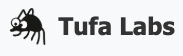

**Note**: this notebook is a more readable version of the notebook that scored our milestone-winning 1.21; unfortunately, we haven't had the same lucky result with this one. The original one is also shared here, but using it is not recommended: https://www.kaggle.com/code/jeroencottaar/taaf-duck-harness-kaggle

**Note**: if you make a copy of this notebook, you will have to manually select the proper GPU (RTX Pro 6000).

Link to writeup explaining what's going on here: https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3/discussion/717133

Link to Machine Learning Street Talk interview by Tim Scarfe about this duck harness: https://x.com/MLStreetTalk/status/2072326433922297975?s=20

This notebook executes the ARC-AGI-3 solver written by the Tufa Labs team; in alphabetical order: Harold Bessis, Jeroen Cottaar, Isaiah Pressman, Andries Smit, Michal Tesnar, and Stefano Viel.

You will only find infrastructure and diagnostics in this notebook; the actual solver code is in an attached dataset. See our writeup on the competition forum to learn more about that the solver actually does.

It installs the ARC runtime from the competition wheelhouse, makes the bundled source
snapshot importable, runs any solver setup commands, loads the pickled benchmark, plays the
competition games, and writes results to `/kaggle/working`. Diagnostics are minimised during
a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`) and kept full otherwise.

## 1. Environment and submission mode

Detect whether this is a real competition rerun (which minimises diagnostics), set the
framework's environment flags, and put the CUDA libraries on the linker path.

In [ ]:
import json
import os
import pickle
import subprocess
import sys
import sysconfig
import time
from datetime import datetime, timedelta
from pathlib import Path
from urllib.request import urlopen

# True only inside a real competition rerun; switches diagnostics + soft deadline.
TRUE_SUBMISSION = os.environ.get("KAGGLE_IS_COMPETITION_RERUN", "").strip().lower() in {"1", "true"}
NOTEBOOK_START_EPOCH = time.time()

# Non-interactive matplotlib backend: diagnostics render plots with no display attached.
os.environ["MPLBACKEND"] = "Agg"
# Marks the run as a (real or emulated) submission so the framework + solver can adjust.
os.environ["TAAF_RUN_AS_SUBMISSION"] = "1" if TRUE_SUBMISSION else "0"
# In submission, disable the periodic JSON/HTML diagnostics writes and per-frame logging.
os.environ["TAAF_MINIMAL_DIAGNOSTICS"] = "1" if TRUE_SUBMISSION else "0"
# Pin arc_agi's cached level_reset_only before its client is built (RESET keeps the level).
os.environ["ONLY_RESET_LEVELS"] = "true"

# Prepend the CUDA toolkit to the linker path (it is off it on Kaggle GPU images) so the
# solver's GPU libraries (e.g. vllm / torch) can link against libcuda.
cuda_library_path = "/usr/local/nvidia/lib64"
os.environ["LIBRARY_PATH"] = os.pathsep.join(
    entry for entry in [cuda_library_path, *os.environ.get("LIBRARY_PATH", "").split(os.pathsep)] if entry
)

# Everything the run produces is written here.
WORKING_DIR = Path("/kaggle/working")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print(f"taaf.kaggle: TRUE_SUBMISSION={TRUE_SUBMISSION}")

## 2. Install the ARC runtime

Install `arc-agi` from the offline competition wheelhouse (the Kaggle submission environment
has no internet).

In [ ]:
# Install the ARC runtime from the bundled competition wheels.
# Quiet: stdout is discarded; stderr (and a non-zero exit) still surface real failures.
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-index",
        "--no-warn-conflicts",
        "--disable-pip-version-check",
        "--find-links",
        "/kaggle/input/competitions/arc-prize-2026-arc-agi-3/arc_agi_3_wheels",
        "arc-agi",
    ],
    stdout=subprocess.DEVNULL,
)

## 3. Locate the source bundle

Find the uploaded TAAF source dataset by its marker file, and record where Kaggle mounted
every attached input so setup commands and the solver can find them.

In [ ]:
# Kaggle inputs attached to this notebook, plus bookkeeping paths used below.
DATASET_SOURCES = ["jeroencottaar/taaf-kaggle-source-share", "driessmit1/arc3-vllm-h100-wheelhouse-v3", "driessmit1/vrfai-qwen3-6-27b-fp8-hf-snapshot"]
KERNEL_SOURCES = []
DATASET_BUNDLE_MARKER = "taaf-kaggle-bundle.json"
SETUP_ENV_PATH = WORKING_DIR / "taaf_setup_env.json"


# Locate the source dataset by its marker file rather than a fixed mount path.
def _find_bundle_dir() -> Path:
    for marker in Path("/kaggle/input").rglob(DATASET_BUNDLE_MARKER):
        return marker.parent
    raise RuntimeError("TAAF source bundle not found under /kaggle/input.")


# Kaggle mounts a dataset at /kaggle/input/<slug> or /kaggle/input/datasets/<owner>/<slug>
# (depending on owner / slug collisions), so probe both and use whichever exists. Utility
# scripts mount under /kaggle/usr/lib/notebooks/<owner>/<slug>.
def _dataset_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/input") / slug, Path("/kaggle/input/datasets") / owner / slug]


def _kernel_mount_candidates(ref: str) -> list[Path]:
    owner, slug = ref.split("/", 1)
    return [Path("/kaggle/usr/lib/notebooks") / owner / slug]


def _first_existing(candidates: list[Path]) -> Path | None:
    return next((c for c in candidates if c.exists()), None)


BUNDLE_DIR = _find_bundle_dir()
print(f"taaf.kaggle: source bundle = {BUNDLE_DIR}")

# Map each attached input to where Kaggle actually mounted it (the source bundle is index 0).
kaggle_input_paths: dict[str, str] = {}
for i, ref in enumerate(DATASET_SOURCES):
    candidates = _dataset_mount_candidates(ref)
    resolved = BUNDLE_DIR if i == 0 else _first_existing(candidates)
    kaggle_input_paths[ref] = str(resolved or candidates[0])
for ref in KERNEL_SOURCES:
    candidates = _kernel_mount_candidates(ref)
    kaggle_input_paths[ref] = str(_first_existing(candidates) or candidates[0])

# Published to setup commands and the solver via the environment:
setup_env = {
    # JSON {ref: mount_path} so they can locate every attached dataset / utility script.
    "TAAF_KAGGLE_INPUT_PATHS": json.dumps(kaggle_input_paths, sort_keys=True),
    # The attached dataset refs in order (index 0 is this source bundle).
    "TAAF_KAGGLE_DATASET_SOURCES": json.dumps(DATASET_SOURCES),
    # The attached utility-script / kernel refs.
    "TAAF_KAGGLE_KERNEL_SOURCES": json.dumps(KERNEL_SOURCES),
}
os.environ.update(setup_env)
SETUP_ENV_PATH.write_text(json.dumps(setup_env, indent=2, sort_keys=True) + "\n")
print(f"taaf.kaggle: input paths = {setup_env['TAAF_KAGGLE_INPUT_PATHS']}")

## 4. Import the bundled source and run solver setup

Put the snapshotted repositories on the path (this process and any child processes), then run
the solver's setup commands — installing wheels, fetching model weights, and so on.

In [ ]:
# Each bundled repo exposes its importable tree at <repo>/src or <repo>.
def _source_path_entries(bundle_dir: Path) -> list:
    entries = []
    for repo in sorted((bundle_dir / "src").iterdir(), reverse=True):
        for candidate in (repo / "src", repo):
            if candidate.is_dir():
                entries.append(candidate)
    return entries


# Environment handed to each setup command (paths + any keys it has persisted).
def _command_env() -> dict:
    env = os.environ.copy()
    # "$PYTHON" in a command resolves to this notebook's interpreter.
    env["PYTHON"] = sys.executable
    # Absolute path to the mounted source bundle.
    env["TAAF_KAGGLE_BUNDLE_DIR"] = str(BUNDLE_DIR)
    # The writable /kaggle/working directory.
    env["TAAF_KAGGLE_WORKING_DIR"] = str(WORKING_DIR)
    # A command writes a JSON object here to persist env keys to later commands + the run.
    env["TAAF_KAGGLE_SETUP_ENV"] = str(SETUP_ENV_PATH)
    env.update({str(k): str(v) for k, v in json.loads(SETUP_ENV_PATH.read_text()).items()})
    return env


# Make the bundled repos importable here (sys.path) and in child processes (.pth).
source_entries = _source_path_entries(BUNDLE_DIR)
for entry in source_entries:
    sys.path.insert(0, str(entry))
pth_path = Path(sysconfig.get_paths()["purelib"]) / "taaf_kaggle_sources.pth"
pth_path.write_text("".join(f"{entry}\n" for entry in source_entries))
print(f"taaf.kaggle: wrote {pth_path} ({len(source_entries)} source roots)")

# Solver setup commands (wheels, vLLM server startup, ...) run before the benchmark loads.
env = _command_env()
if True:  # rig: force the serve — a commit run must serve Qwen
    for command in json.loads((BUNDLE_DIR / "setup_commands.json").read_text()):
        print(f"taaf.kaggle: setup command: {command}", flush=True)
        subprocess.run(command, shell=True, check=True, cwd=WORKING_DIR, env=env)
        env = _command_env()
        os.environ.update(env)
else:
    print("[duck] commit: skipping setup_commands (no GPU serve)", flush=True)

# Honour any PYTHONPATH a setup command exported.
for entry in reversed([e for e in os.environ.get("PYTHONPATH", "").split(os.pathsep) if e]):
    if entry not in sys.path:
        sys.path.insert(0, entry)

## 5. Load the benchmark

Unpickle the deployment target and the benchmark, stamping the real submission state onto the
target and pointing the benchmark's outputs at the Kaggle working directory.

In [ ]:
# Restore the deployment target and record the real submission state on it.
with open(BUNDLE_DIR / "deploy_target.pkl", "rb") as file:
    target = pickle.load(file)
target.actual_run_as_submission = TRUE_SUBMISSION
target.is_competition_rerun = TRUE_SUBMISSION

# Restore the benchmark and point its outputs at the Kaggle working dir.
with open(BUNDLE_DIR / "benchmark_initial.pkl", "rb") as file:
    bm = pickle.load(file)
bm.job_dir = WORKING_DIR

## 6. Customization hook

Optional: tweak `bm`, `bm.games`, or `bm.solver` here before the run starts — the safe place
for one-off experiments once the deployed bundle has loaded.

In [ ]:
print("[rig] pack: none (label=base)", flush=True)

# --- behavioural probe: identical in every arm, observes only ---
"""Per-action behavioural instrumentation. Observes only; changes nothing.

WHY THIS EXISTS. Scoring a rig run is low-power: 28 games, near-binary outcomes, and
17 of 28 flip between identical repeats (measured). A 3-repeat score A/B sits at the
noise floor. But the *mechanism* an arm claims to affect is a PER-ACTION quantity with
~1,600 samples per run — roughly 50x the statistical power on the same GPU minutes.

So we measure whether the agent's behaviour changed in the intended direction, and
leave score to the one instrument that actually measures the hidden set: a submission.

WHAT IT MEASURES, with the human benchmarks it is judged against:
  dead_reissue     re-issuing a (board, action) pair already observed to do nothing,
                   state-conditioned. Humans 3.4%; our agent 27.1% unconditioned.
                   This is the quantity the board_changed fix should move.
  noop_raw         action left the frame byte-identical (what the harness believes)
  noop_masked      action left the BOARD identical, HUD excluded (the truth)
  immediate_repeat same action twice in a row. Humans 68% overall, 52% keys, 10.6% clicks.
  distinct_states  exploration efficiency: unique masked boards per action

IT MUST BE IDENTICAL IN BOTH ARMS. It carries its own HUD table and stem resolution
rather than importing the arm under test, so the baseline arm is instrumented exactly
like the treatment arm and the instrument cannot become the difference between them.

It wraps OUTSIDE any arm patch (applied last), so it observes the final executed
action either way. It never mutates the payload.
"""
from __future__ import annotations

import re

import numpy as np

HUD_REGIONS: dict[str, tuple] = {
    "cd82": ("row", 63), "dc22": ("row", 63), "ka59": ("row", 63), "re86": ("row", 63),
    "s5i5": ("row", 63), "tu93": ("row", 63), "wa30": ("row", 63), "bp35": ("row", 63),
    "tr87": ("row", 63),
    "cn04": ("row", 0), "vc33": ("row", 0), "sp80": ("row", 0), "lf52": ("row", 0),
    "sk48": ("row", 53), "sb26": ("row", 53),
    "r11l": ("col", 0), "lp85": ("col", 0),
    "ls20": ("rows", (61, 62)),
}
_CLONE = re.compile(r"^k\d{3}$")
_mask_cache: dict[tuple, np.ndarray | None] = {}
_stem_cache: dict[int, str] = {}

# per game stem -> counters
_G: dict[str, dict] = {}
_unresolved = {"n": 0}


def _stem(g: str) -> str:
    return str(g).split("-")[0][:4].lower()


def _resolve(game) -> str:
    key = id(game)
    hit = _stem_cache.get(key)
    if hit is not None:
        return hit
    cand = str(getattr(game, "env_name", "") or getattr(game, "game_id", "") or "")
    if _CLONE.match(cand):
        got = ""
        for path in ("env", "_env"):
            env = getattr(game, path, None)
            info = getattr(env, "environment_info", None) if env is not None else None
            t = str(getattr(info, "title", "") or "")
            if t:
                got = t
                break
        if got:
            cand = got
        else:
            _unresolved["n"] += 1
    out = _stem(cand)
    _stem_cache[key] = out
    return out


def _mask(stem: str, shape):
    key = (stem, tuple(shape))
    if key in _mask_cache:
        return _mask_cache[key]
    spec = HUD_REGIONS.get(stem)
    m = None
    if spec is not None:
        m = np.zeros(shape, dtype=bool)
        kind, val = spec
        if kind == "row":
            m[val, :] = True
        elif kind == "col":
            m[:, val] = True
        else:
            for r in val:
                m[r, :] = True
    _mask_cache[key] = m
    return m


def _key(grid, stem) -> bytes:
    a = np.asarray(grid)
    m = _mask(stem, a.shape)
    if m is not None and m.any():
        a = np.where(m, 0, a)
    return np.ascontiguousarray(a, dtype=np.int8).tobytes()


def _slot(stem: str) -> dict:
    return _G.setdefault(stem, {
        "actions": 0, "noop_raw": 0, "noop_masked": 0,
        "dead_reissue": 0, "reissue_opportunities": 0,
        "immediate_repeat": 0, "key_actions": 0, "key_repeat": 0,
        "click_actions": 0, "click_repeat": 0,
        "_seen": {}, "_states": set(), "_last": None,
    })


def install() -> bool:
    from inference.framework import solver as sv

    original = sv._HarnessGameSession._execute_action
    if getattr(original, "_behav", False):
        return True

    def _execute_action(self, action, **kwargs):
        stem = _resolve(self.game)
        prev = sv._grid_from_state(self.game.current_state)
        payload = original(self, action, **kwargs)
        try:
            s = _slot(stem)
            cur = sv._grid_from_state(self.game.current_state)
            pa, ca = np.asarray(prev), np.asarray(cur)
            pk, ck = _key(pa, stem), _key(ca, stem)

            name = getattr(getattr(action, "id", None), "name", "?")
            data = dict(getattr(action, "data", {}) or {})
            akey = (name, data.get("x"), data.get("y")) if name == "ACTION6" else (name,)

            s["actions"] += 1
            s["noop_raw"] += int(np.array_equal(pa, ca))
            changed = pk != ck
            s["noop_masked"] += int(not changed)
            s["_states"].add(ck)

            if name == "ACTION6":
                s["click_actions"] += 1
                s["click_repeat"] += int(s["_last"] == akey)
            else:
                s["key_actions"] += 1
                s["key_repeat"] += int(s["_last"] == akey)
            s["immediate_repeat"] += int(s["_last"] == akey)
            s["_last"] = akey

            # State-conditioned dead-action memory: have we been at THIS board and
            # taken THIS action before, and did it do nothing?
            memo = s["_seen"]
            mk = (pk, akey)
            if mk in memo:
                s["reissue_opportunities"] += 1
                if memo[mk] is False:
                    s["dead_reissue"] += 1
            memo[mk] = changed
        except Exception:
            pass          # observation must never affect the run
        return payload

    _execute_action._behav = True
    sv._HarnessGameSession._execute_action = _execute_action
    return True


def report() -> dict:
    per = {}
    tot = {k: 0 for k in ("actions", "noop_raw", "noop_masked", "dead_reissue",
                          "reissue_opportunities", "immediate_repeat",
                          "key_actions", "key_repeat", "click_actions", "click_repeat")}
    states = 0
    for stem, s in _G.items():
        n = max(s["actions"], 1)
        per[stem] = {
            "actions": s["actions"],
            "noop_raw": round(s["noop_raw"] / n, 4),
            "noop_masked": round(s["noop_masked"] / n, 4),
            "dead_reissue_of_actions": round(s["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                s["dead_reissue"] / max(s["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(s["immediate_repeat"] / n, 4),
            "distinct_states_per_action": round(len(s["_states"]) / n, 4),
        }
        for k in tot:
            tot[k] += s[k]
        states += len(s["_states"])
    n = max(tot["actions"], 1)
    return {
        "unresolved_games": _unresolved["n"],
        "n_games": len(_G),
        "corpus": {
            "actions": tot["actions"],
            "noop_raw": round(tot["noop_raw"] / n, 4),
            "noop_masked": round(tot["noop_masked"] / n, 4),
            # The headline. Humans 3.4%; our agent 27.1% unconditioned.
            "dead_reissue_of_actions": round(tot["dead_reissue"] / n, 4),
            "dead_reissue_of_opportunities": round(
                tot["dead_reissue"] / max(tot["reissue_opportunities"], 1), 4),
            "immediate_repeat": round(tot["immediate_repeat"] / n, 4),
            "key_repeat": round(tot["key_repeat"] / max(tot["key_actions"], 1), 4),
            "click_repeat": round(tot["click_repeat"] / max(tot["click_actions"], 1), 4),
            "distinct_states_per_action": round(states / n, 4),
        },
        "per_game": per,
    }


def assert_observed(min_actions: int = 50) -> None:
    r = report()
    if r["unresolved_games"]:
        raise RuntimeError(f"[behav] {r['unresolved_games']} games had unresolvable stems — "
                           "HUD masking in the probe is unreliable, refusing to report")
    if r["corpus"]["actions"] < min_actions:
        raise RuntimeError(f"[behav] only {r['corpus']['actions']} actions observed — "
                           "not enough to compare arms")

if not install():
    raise RuntimeError("[rig] behavioural probe failed to install")
behav_report = report
behav_assert = assert_observed
print("[rig] behavioural probe ACTIVE", flush=True)


## 7. Run the benchmark

In a real competition rerun (`KAGGLE_IS_COMPETITION_RERUN`), wait for the Kaggle gateway and
play the **live competition Arcade**. Otherwise — an interactive "Save & Run" — play the
competition's **bundled environment files offline**, with no gateway required, so the notebook
runs end-to-end without a submission. Teardown commands run afterward even if the run raises.

In [ ]:
# rig: competition-simulated run. Replaces duck-base's submission cell, whose
# gateway poll cannot succeed in a commit run.
#
# EVERYTHING is wrapped and a diagnostic file is written unconditionally: an ERRORed
# Kaggle kernel produces NO retrievable log (verified — a COMPLETE run yields a .log,
# an ERROR run does not), so a rig that dies silently teaches us nothing and costs an
# hour of quota. Files written to the working dir DO survive an error.
import json, time, traceback

_t0 = time.time()
_stage = "init"
_err = None
_rows = []
_rig = None
_all_repeats = []

def _dump(extra=None):
    _o = {"label": "base", "pack": "", "per_game_budget": 1800.0,
          "config": globals().get("_cfg"), "clone_map": globals().get("_map"),
          "stage": _stage, "elapsed_s": round(time.time() - _t0, 1),
          "error": _err, "n_games": len(_rows), "rows": _rows}
    if extra:
        _o.update(extra)
    (WORKING_DIR / "rig_result.json").write_text(json.dumps(_o, indent=1, default=str))

try:
    _stage = "preamble"
    print((BUNDLE_DIR / "preamble.txt").read_text())
    os.environ.setdefault("RECORDINGS_DIR", str(WORKING_DIR / "server_recording"))

    # NOTE: taaf.standard_benchmarks.make_benchmark_kaggle_official_110 imports `re_arc`
    # to list the 25 official ids. That package is NOT in the shipped bundle and not in
    # the Kaggle image — it is what killed the first rig run. Build the same thing from
    # the offline arcade instead, which the competition dataset already provides.
    # Proof of what actually ran. If sampling or context drifted, an arm comparison is
    # meaningless — record it rather than trusting the build.
    _stage = "config_snapshot"
    from inference.agent import tool_agent as _ta_cfg
    _cfg = {
        "temperature": float(_ta_cfg._LOCAL_ANALYZER_TEMPERATURE),
        "top_k": int(_ta_cfg._LOCAL_ANALYZER_TOP_K),
        "top_p": float(_ta_cfg._LOCAL_ANALYZER_TOP_P),
        "seed": int(_ta_cfg._LOCAL_ANALYZER_SEED),
        "context_window": int(_ta_cfg._LOCAL_ANALYZER_CONTEXT_WINDOW),
        "concurrency": getattr(bm.solver, "concurrency", None),
        "per_game_budget": 1800.0,
        "n_games": 28,
        "n_repeats": 1,
        "model": str(getattr(getattr(bm.solver, "analyzer_model", None), "model_id", "")) or None,
        "bundle_dir": str(BUNDLE_DIR),
        "estimator_chars_per_token": round(
            len(__import__("json").dumps({"a": "x" * 300})) / _ta_cfg._estimate_tokens({"a": "x" * 300}), 2),
    }
    print(f"[rig] config {_cfg}", flush=True)

    _stage = "official_ids"
    import arc_agi, taaf.game_api, taaf.competition_arcade as _ca, taaf.benchmark
    _env_dir = os.environ.get("ARC_ENVIRONMENTS_DIR", "/kaggle/input/arc-prize-2026-arc-agi-3/environment_files")
    if not os.path.isdir(_env_dir):
        import glob as _g
        _cands = _g.glob("/kaggle/input/**/environment_files", recursive=True)
        if not _cands:
            raise RuntimeError("no environment_files directory found under /kaggle/input")
        _env_dir = _cands[0]
    _arc = arc_agi.Arcade(operation_mode=arc_agi.OperationMode.OFFLINE, environments_dir=_env_dir)
    _official = sorted(e.game_id for e in _arc.available_environments)
    print(f"[rig] env_dir={_env_dir} official={len(_official)}", flush=True)
    if len(_official) != 25:
        raise RuntimeError(f"expected 25 official environments, got {len(_official)}")

    # ArcadeSpec(competition_sim=True) is NOT usable here: it lazily calls
    # CompetitionArcadeServer.official_110(), which calls official_game_ids(), which
    # imports re_arc — absent from both the bundle and the Kaggle image. Construct the
    # server directly with explicit game_ids instead.
    #
    # REPEATS give independent runs of the SAME config inside one kernel. Each repeat
    # gets a fresh server and therefore a fresh scorecard, because competition mode
    # permits exactly one run per game id. This is what makes rho estimable: split the
    # games of each repeat into two disjoint halves and correlate the half-means ACROSS
    # repeats, which separates run-level noise (shared by both halves) from game-level
    # noise (independent) — exactly the decomposition that decides whether selecting on
    # the public half tells you anything about the private half.
    _all_repeats = []
    for _rep in range(1):
        _stage = f"start_arcade_server[{_rep}]"
        _srv = _ca.CompetitionArcadeServer(
            game_ids=tuple(_official), total_runs=28, environments_dir=_env_dir,
        ).start()
        globals()["_rig_server_%d" % _rep] = _srv
        _spec = _srv.arcade_spec
        _clones = _srv.exposed_game_ids
        if len(_clones) != 28:
            raise RuntimeError(f"expected 28 clones, got {len(_clones)}")

        # AUTHORITATIVE clone->source mapping, read from the private tag the cloner
        # writes, and cross-checked against the modulo reconstruction. Getting this
        # join wrong would silently score every game against the wrong baselines.
        _map = {}
        for _ei in _srv._arcade.available_environments:
            _src = None
            for _t in (getattr(_ei, "private_tags", None) or []):
                if str(_t).startswith("taaf_source_game:"):
                    _src = str(_t).split(":", 1)[1]
            _map[_ei.game_id] = _src
        _recon = {f"k{i:03d}": _official[i % len(_official)] for i in range(len(_clones))}
        _mismatch = {k: (v, _recon.get(k)) for k, v in _map.items() if v != _recon.get(k)}
        if _mismatch:
            raise RuntimeError(f"clone->source mapping disagrees with reconstruction: {_mismatch}")
        if any(v is None for v in _map.values()):
            raise RuntimeError(f"clone->source mapping incomplete: {_map}")

        _stage = f"build_benchmark[{_rep}]"
        _games = [taaf.game_api.GameAPI(env_name=_g2, arcade_spec=_spec) for _g2 in _clones]
        _rig = taaf.benchmark.Benchmark(label=f"rig_base_{_rep}", games=_games,
                                        solver=bm.solver, n_passes=1)
        for _attr in ("max_runtime_s_per_game", "max_runtime_s"):
            if hasattr(_rig.solver, _attr):
                setattr(_rig.solver, _attr, 1800.0)
        print(f"[rig] repeat {_rep}: {len(_rig.games)} games @ 1800.0s "
              f"arcade={_srv.base_url}", flush=True)

        _stage = f"run[{_rep}]"
        await _rig.run(soft_end_time=None, runtime_environment=target, minimal_diagnostics=False)

        _stage = f"collect[{_rep}]"
        _rrows = []
        for _gr in (getattr(_rig, "game_runs", None) or []):
            # final_score is 0.0 BY DESIGN here: _compute_final_score returns 0.0 when
            # base_actions_per_level is None, and the competition arcade hides baselines
            # exactly as a real submission does. Record the RAW COMPONENTS and score
            # offline against environment_files/*/metadata.json, which we hold locally.
            _cid = getattr(_gr, "game_id", None)
            _apl = list(getattr(_gr, "actions_per_level", []) or [])
            _hist = len(getattr(_gr, "history", []) or [])
            _rrows.append({
                "clone_id": _cid,
                "source_game": _map.get(_cid),
                "levels_completed": getattr(_gr, "levels_completed", None),
                "levels_total": getattr(_gr, "number_of_levels", None),
                "actions_per_level": _apl,
                "actions_total": _hist,
                # Invariant the harness documents: sum(actions_per_level)==len(history).
                # Logged rather than assumed so a violation is visible in the data.
                "apl_sum_matches_history": (sum(_apl) == _hist),
                "state": str(getattr(_gr, "state", None)),
                "wallclock_s": getattr(_gr, "final_wallclock_seconds", None),
                "gen_tokens": getattr(_gr, "final_generated_tokens", None),
                # Expected None in competition mode (baselines hidden). Logged to PROVE
                # that is why final_score is 0.0, rather than inferring it.
                "base_actions_per_level": getattr(_gr, "base_actions_per_level", None),
                "harness_final_score": getattr(_gr, "final_score", None),
            })
        # EFFECT GATE. Verifying that a patch installed proves nothing — this arm's
        # stem-resolution bug made it a behavioural no-op while every install check
        # passed. Demand evidence it actually changed something.
        try:
            _bfstats = board_fix_stats()  # type: ignore[name-defined]
        except Exception:
            _bfstats = None
        try:
            _behav = behav_report()  # type: ignore[name-defined]
            print(f"[rig] behav after repeat {_rep}: {_behav['corpus']}", flush=True)
            globals()["_behav_last"] = _behav
            if _rep == 0:
                behav_assert()  # type: ignore[name-defined]
        except Exception as _e:
            print(f"[rig] behav report unavailable: {_e!r}", flush=True)
        if _bfstats is not None:
            print(f"[rig] boardfix stats after repeat {_rep}: {_bfstats}", flush=True)
            globals()["_bf_stats_last"] = _bfstats
            if _rep == 0:
                board_fix_assert()  # type: ignore[name-defined]
        _all_repeats.append(_rrows)
        _rows = list(_rrows)   # copy — sharing the object let the post-loop collector
                               # append into _all_repeats[-1] and report 56 games, not 28
        _sc = [r["score"] for r in _rrows if isinstance(r.get("score"), (int, float))]
        print(f"[rig] repeat {_rep} done: n={len(_sc)} "
              f"mean={(sum(_sc)/len(_sc)) if _sc else float('nan'):.4f}", flush=True)
        _dump({"repeats": _all_repeats})
        try:
            _srv.stop()
        except Exception:
            pass
    _stage = "collect"
except Exception:
    _err = traceback.format_exc()
    print(f"[rig] FAILED at stage={_stage}:\n{_err}", flush=True)

# Shape probe only — the per-repeat collector above is authoritative. An earlier
# version re-collected here into the same list object and reported 56 games for a
# 28-game repeat, mixing two row schemas.
_probe = None
try:
    _first = (getattr(_rig, "game_runs", None) or [None])[0]
    if _first is not None:
        _probe = [a for a in dir(_first) if not a.startswith("__")][:60]
except Exception:
    pass
_dump({"game_run_attrs": _probe, "repeats": _all_repeats,
       "boardfix_stats": globals().get("_bf_stats_last"),
       "behav": globals().get("_behav_last")})

# NOTE: harness_final_score is 0.0 by design here (baselines hidden), so progress is
# reported as levels completed. Real scores are computed offline by score_rig.py.
_lvl = [r.get("levels_completed") or 0 for rr in _all_repeats for r in rr]
_act = [r.get("actions_total") or 0 for rr in _all_repeats for r in rr]
if _lvl:
    print(f"[rig] RESULT label=base repeats={len(_all_repeats)} games={len(_lvl)} "
          f"mean_levels={sum(_lvl)/len(_lvl):.3f} games_with_level={sum(1 for x in _lvl if x>0)} "
          f"mean_actions={sum(_act)/max(len(_act),1):.1f}", flush=True)
else:
    print(f"[rig] RESULT label=base — NO ROWS (stage={_stage})", flush=True)
print(f"[rig] DONE stage={_stage} in {round(time.time()-_t0,1)}s", flush=True)


## 8. Show the diagnostics

A non-submission run writes `diagnostics.html` to `/kaggle/working`; it is rendered inline below
(and downloadable from the working directory). You should be able to click around through the links.

In [ ]:
from html import escape

from IPython.display import HTML, display

diagnostics_html = WORKING_DIR / "diagnostics.html"
if diagnostics_html.is_file():
    # Isolate the full document in an iframe so its styles don't leak into the notebook.
    display(
        HTML(
            f'<iframe srcdoc="{escape(diagnostics_html.read_text(), quote=True)}" '
            'width="100%" height="900" style="border:0"></iframe>'
        )
    )
else:
    print("No diagnostics.html — minimal diagnostics (real submission) suppresses it.")